# 03. Predictive CLV: Benchmarks, Suitability, and Influence

**Project:** Customer Churn Prediction & Lifetime Value.

**Source material:** Katherine Munro, *"From Probabilistic to Predictive: CLV"*
(Towards Data Science), presents BG-NBD + Gamma-Gamma as the natural next step up from
a naive rate extrapolation, and sketches an ML alternative alongside it. Munro's
earlier piece, *"Methods for Modelling CLV,"* is also relevant here: its critique that
a simple historic-rate formula "assumes constant spending" going forward is the direct
reason the naive baseline below gets tested explicitly rather than dismissed by
assumption.

**This notebook covers:**
1. Building calibration-only features for the 1,926 eligible repeat customers
2. A naive historic-rate baseline, a train-fitted ML revenue model, and a **separate**
   conditional-active spend estimate (used later as notebook 5's false-negative cost
   proxy)
3. A suitability gate for BG-NBD/Gamma-Gamma -- checked numerically, not assumed to work
4. Head-to-head validation accuracy, with a look at how much one large customer moves
   the comparison, and what each ML model actually leaned on

**Question:** how well can September 1 information predict September-November revenue
for established customers? The first iteration found BG-NBD/Gamma-Gamma genuinely
struggled on this dataset -- degenerate dropout parameters, a `q < 1` Gamma-Gamma fit
that makes its own mean formula undefined. This notebook checks that again on the
redefined population, with an explicit pass/fail gate instead of eyeballing whether the
numbers "look reasonable" first. That gate, and the conditional-active model introduced
in Section 2, are both this project's own additions -- neither is something the source
article specifies, and both exist because the article's own recommended technique
turned out not to be usable here.

### Import necessary libraries

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

CALIBRATION_END = pd.Timestamp("2011-09-01")
OBSERVATION_END = pd.Timestamp("2011-12-01")
DATA_START = pd.Timestamp("2010-12-01")
HORIZON_DAYS = (OBSERVATION_END - CALIBRATION_END).days

### Load & Inspect data

In [2]:
# Resolve repository paths whether Jupyter is launched from the
# repository root or from the notebooks directory.
REPO_ROOT = Path.cwd()

if not (REPO_ROOT / 'data').exists():
    REPO_ROOT = REPO_ROOT.parent

RAW_DATA = REPO_ROOT / 'data' / 'raw'
PROCESSED_DATA = REPO_ROOT / 'data' / 'processed'

In [3]:
clean = pd.read_parquet(PROCESSED_DATA / "online_retail_clean.parquet")
manifest = pd.read_parquet(PROCESSED_DATA / "retail_population_manifest.parquet")
rfm = pd.read_parquet(PROCESSED_DATA / "retail_rfm.parquet")

tx = clean.copy()
tx["InvoiceDate"] = pd.to_datetime(tx["InvoiceDate"])
tx["TotalPrice"] = tx["Quantity"] * tx["UnitPrice"]
assert tx["InvoiceDate"].lt(OBSERVATION_END).all()

print(f"Transactions: {len(tx):,}   Eligible repeat customers: {manifest['eligible_repeat'].sum():,}")

Transactions: 371,767   Eligible repeat customers: 1,926


## 1. Calibration-only features, holdout revenue kept separate

The calibration/holdout split itself -- fitting on a first window, scoring against a
later one -- is the article's own methodology, not just this project's decision-clock
discipline from notebook 1; Munro's "From Probabilistic to Predictive" piece uses the
same structure to evaluate BG-NBD/Gamma-Gamma against an ML alternative, and it's
applied identically to both here so neither approach gets an easier test.

Every feature below uses only calibration-period (pre-September) information. Holdout
revenue is computed too, but it's the *outcome* this notebook is trying to predict --
never a predictor, and never merged into the feature columns models are trained on.

In [4]:
orders = (tx.groupby(["CustomerID", "InvoiceNo"], as_index=False)
          .agg(date=("InvoiceDate", "min"), revenue=("TotalPrice", "sum")))
cal_orders = orders.loc[orders["date"] < CALIBRATION_END]
holdout_orders = orders.loc[(orders["date"] >= CALIBRATION_END) & (orders["date"] < OBSERVATION_END)]

features = (cal_orders.groupby("CustomerID").agg(
    orders_cal=("InvoiceNo", "size"),
    first_cal=("date", "min"),
    last_cal=("date", "max"),
    revenue_cal=("revenue", "sum"),
    mean_order_value_cal=("revenue", "mean")).reset_index())

eligible_ids = manifest.loc[manifest["eligible_repeat"], ["CustomerID", "split", "churned"]]
features = features.merge(eligible_ids, on="CustomerID", how="inner", validate="one_to_one")
print(f"Feature rows: {len(features):,} (should match the 1,926 eligible repeat customers)")

Feature rows: 1,926 (should match the 1,926 eligible repeat customers)


In [5]:
features["recency_days_cal"] = (CALIBRATION_END - features["last_cal"]).dt.days
features["tenure_days_cal"] = (CALIBRATION_END - features["first_cal"]).dt.days.clip(lower=1)
features["purchase_span_days_cal"] = (features["last_cal"] - features["first_cal"]).dt.days
features["orders_per_30_days_cal"] = features["orders_cal"] * 30.44 / features["tenure_days_cal"]
features["recency_to_tenure_cal"] = features["recency_days_cal"] / features["tenure_days_cal"]

holdout_revenue_by_customer = holdout_orders.groupby("CustomerID")["revenue"].sum()
features["holdout_revenue"] = features["CustomerID"].map(holdout_revenue_by_customer).fillna(0.0)

# holdout_revenue and the notebook 2 churn label describe the same fact two ways --
# worth a direct check that they agree
assert features["churned"].eq(features["holdout_revenue"].eq(0).astype(int)).all()

FEATURE_COLS = ["orders_cal", "revenue_cal", "mean_order_value_cal", "recency_days_cal",
                "tenure_days_cal", "purchase_span_days_cal", "orders_per_30_days_cal",
                "recency_to_tenure_cal"]
features = features.merge(rfm[["CustomerID", "segment"]], on="CustomerID", validate="one_to_one")
features.groupby("split").size().rename("n")

split
test           386
train         1155
validation     385
Name: n, dtype: int64

## 2. Three estimates, three different jobs

- **Naive** -- extrapolate each customer's own calibration spending rate across the
  91-day holdout. No fitting, no training population -- it's a per-customer arithmetic
  rate, so it can be computed for every split at once. This is the baseline Munro's
  "Methods for Modelling CLV" critiques for assuming constant spending going forward;
  it's tested head-to-head here rather than dismissed on that basis alone.
- **ML (unconditional)** -- a gradient-boosted regressor fit on **train** customers
  only, predicting log(1 + holdout revenue) from the calibration features. This is the
  ML alternative Munro's "From Probabilistic to Predictive" sketches alongside
  BG-NBD/Gamma-Gamma, and the head-to-head competitor to the naive baseline below.
- **ML (conditional-active)** -- **not in the source article.** The same model
  architecture, but fit only on train customers who actually purchased in the holdout
  (`holdout_revenue > 0`). This one answers a different question -- "if this customer
  buys again, how much would they likely spend?" -- and it's kept separate on purpose:
  an *unconditional* forecast can legitimately approach zero for a customer who's
  unlikely to buy again, and using that as "the cost of missing them" would make the
  highest-risk customers look artificially cheap to lose. Notebook 5 needs the
  conditional number for exactly that reason -- a need the article never has to solve,
  since Oliveira's subscription-business setup prices a missed customer from CAC and
  ARPU rather than from a predicted future purchase at all.

In [6]:
train_mask = features["split"].eq("train")
X = features[FEATURE_COLS].replace([np.inf, -np.inf], np.nan).fillna(0)
assert X.notna().all().all()

# Naive: this customer's own calibration rate, extrapolated across the holdout window
features["pred_revenue_naive"] = (features["revenue_cal"] / features["tenure_days_cal"]
                                  * HORIZON_DAYS).clip(lower=0)

# Unconditional ML: fit on train, log1p target to tame the heavy right tail
ml_model = GradientBoostingRegressor(random_state=42, loss="huber", n_estimators=100, max_depth=2)
ml_model.fit(X.loc[train_mask], np.log1p(features.loc[train_mask, "holdout_revenue"]))
features["pred_revenue_ml"] = np.expm1(ml_model.predict(X)).clip(min=0)

# Conditional-active ML: same architecture, fit only on train customers who bought again
active_train = train_mask & features["holdout_revenue"].gt(0)
print(f"Active train customers for the conditional model: {active_train.sum():,} of {train_mask.sum():,}")
active_model = GradientBoostingRegressor(random_state=42, loss="huber", n_estimators=100, max_depth=2)
active_model.fit(X.loc[active_train], np.log1p(features.loc[active_train, "holdout_revenue"]))
features["pred_revenue_if_active"] = np.expm1(active_model.predict(X)).clip(min=0)

Active train customers for the conditional model: 808 of 1,155


## 3. A suitability gate for BG-NBD / Gamma-Gamma

Munro's article frames BG-NBD/Gamma-Gamma as the more principled alternative to both
the naive baseline and a plain ML regressor: BG-NBD learns purchase frequency and
"probability alive" from calibration recency/frequency/tenure, Gamma-Gamma separately
learns typical transaction value, and the two are multiplied together to get predicted
future revenue. The article presents the technique; it doesn't include a numerical
health-check for when the fit is degenerate, and that check -- not the technique
itself -- is where this section departs from the source material.

The first iteration's biggest debugging effort was here: convergence failures traced to
wholesale-scale accounts, a stopping-criterion bug where "no `ConvergenceError`" didn't
actually mean the fit was numerically sound, and -- even after a clean fit --
dropout-rate parameters that collapsed to `p(alive) ~ 1.0` for nearly the whole customer
base. This notebook doesn't re-run that whole diagnostic history; instead it checks the
one condition that determines whether Gamma-Gamma's output is even mathematically
defined, and refuses to report a number if it isn't.

Gamma-Gamma's population-mean-transaction-value formula requires its shape parameter
`q > 1`. If the fit comes back with `q <= 1`, the model's mean is undefined -- not
unreliable, *undefined* -- so the right response is to report zero usable coverage and
exclude it from the head-to-head comparison below, rather than quietly filling the gap
with an ML prediction or reporting a number that doesn't mean what it looks like it
means.

In [7]:
from lifetimes import BetaGeoFitter, GammaGammaFitter

prob_status = "not attempted"
features["pred_revenue_prob"] = np.nan

try:
    repeat_orders = (cal_orders.sort_values(["CustomerID", "date"])
                     .assign(order_number=lambda d: d.groupby("CustomerID").cumcount()))
    repeat_mean_value = (repeat_orders.loc[repeat_orders["order_number"].gt(0)]
                         .groupby("CustomerID")["revenue"].mean())

    lifetimes_input = features[["CustomerID", "orders_cal", "first_cal", "last_cal"]].set_index("CustomerID")
    lifetimes_input["frequency"] = lifetimes_input["orders_cal"] - 1  # repeat orders only
    lifetimes_input["recency"] = (lifetimes_input["last_cal"] - lifetimes_input["first_cal"]).dt.days
    lifetimes_input["T"] = (CALIBRATION_END - lifetimes_input["first_cal"]).dt.days
    lifetimes_input["monetary"] = repeat_mean_value.reindex(lifetimes_input.index)

    train_ids = set(features.loc[train_mask, "CustomerID"])
    # Wholesale-scale accounts break the "buy till you die" assumption -- cap at the
    # train population's own 99th percentile rather than an arbitrary number
    freq_cap = lifetimes_input.loc[lifetimes_input.index.isin(train_ids), "frequency"].quantile(0.99)
    fit_pop = lifetimes_input.loc[lifetimes_input.index.isin(train_ids)
                                  & lifetimes_input["frequency"].le(freq_cap)
                                  & lifetimes_input["monetary"].gt(0)]

    bg = BetaGeoFitter(penalizer_coef=0.1).fit(fit_pop["frequency"], fit_pop["recency"], fit_pop["T"])
    gg = GammaGammaFitter(penalizer_coef=0.1).fit(fit_pop["frequency"], fit_pop["monetary"])

    if not np.isfinite(list(bg.params_.values)).all() or not np.isfinite(list(gg.params_.values)).all():
        raise ValueError("non-finite BG-NBD/Gamma-Gamma coefficients")
    if gg.params_["q"] <= 1:
        raise ValueError(f"Gamma-Gamma q={gg.params_['q']:.3f} <= 1; population mean is undefined")

    repeat_value = gg.conditional_expected_average_profit(
        lifetimes_input["frequency"], lifetimes_input["monetary"].fillna(0))
    expected_orders = bg.conditional_expected_number_of_purchases_up_to_time(
        HORIZON_DAYS, lifetimes_input["frequency"], lifetimes_input["recency"], lifetimes_input["T"])
    raw_prediction = pd.Series(np.asarray(repeat_value) * np.asarray(expected_orders),
                               index=lifetimes_input.index)
    features["pred_revenue_prob"] = features["CustomerID"].map(
        raw_prediction.where(np.isfinite(raw_prediction) & raw_prediction.ge(0)))
    prob_status = f"usable; BG fit n={len(fit_pop)}, frequency cap={freq_cap}, GG q={gg.params_['q']:.3f}"
except Exception as exc:
    prob_status = f"not usable: {type(exc).__name__}: {exc}"

print("Probabilistic benchmark:", prob_status)
print(f"Probabilistic prediction coverage: {features['pred_revenue_prob'].notna().mean():.1%}")

Probabilistic benchmark: not usable: ValueError: Gamma-Gamma q=0.184 <= 1; population mean is undefined
Probabilistic prediction coverage: 0.0%


**Gamma-Gamma fails the `q > 1` gate**, exactly as the first iteration found --
this project's large one-time/infrequent-buyer population starves the dropout and
monetary-value estimation of the signal these models need. The probabilistic benchmark
gets **0% usable coverage** and is excluded from the numeric comparison below rather
than reported as a number that isn't mathematically meaningful. This says something
specific about *this dataset's* fit for BG-NBD/Gamma-Gamma, not a general claim about
the technique.

## 4. Compare prediction errors on the same validation customers

Individual MAE measures a typical customer's absolute error. Aggregate error -- the sum
of forecasts minus the sum of actuals -- measures something different: a model whose
customer-level errors happen to cancel out can post a small aggregate miss while still
being a poor predictor for any one person.

In [8]:
validation = features.loc[features["split"].eq("validation")].copy()

comparison_rows = []
for name, col in [("naive", "pred_revenue_naive"), ("ml", "pred_revenue_ml"),
                   ("probabilistic_covered", "pred_revenue_prob")]:
    covered = validation.loc[validation[col].notna()]
    if len(covered) == 0:
        continue
    error = covered[col] - covered["holdout_revenue"]
    comparison_rows.append({"model": name, "n": len(covered), "mae": abs(error).mean(),
                            "total_predicted": covered[col].sum(),
                            "total_actual": covered["holdout_revenue"].sum(),
                            "aggregate_error": error.sum()})
comparison = pd.DataFrame(comparison_rows)
comparison

,model,n,mae,total_predicted,total_actual,aggregate_error
0,naive,385,900.709914,382399.015830,525768.73,-143369.714170
1,ml,385,996.920001,224452.474952,525768.73,-301316.255048


**Validation result (n = 385).** Naive MAE comes in at **£900.71** against ML's
**£996.92** -- the simple rate-extrapolation baseline beats the trained model on typical
customer-level error. Actual holdout revenue totaled **£525,768.73**; naive's forecasts
summed to £382,399.02 and ML's to £224,452.47, so both under-predict in aggregate too.

### How much does one customer move this?

A £900 vs £997 gap on 385 customers is small enough that it's worth checking whether
it's a broad pattern or a few outliers. The largest single-customer ML error is a good
place to look.

In [9]:
validation["ml_abs_error"] = (validation["pred_revenue_ml"] - validation["holdout_revenue"]).abs()
outlier = validation.loc[validation["ml_abs_error"].idxmax()]
print("Largest ML error, single customer:")
print(outlier[["CustomerID", "holdout_revenue", "pred_revenue_naive", "pred_revenue_ml"]].to_string())

Largest ML error, single customer:
CustomerID                   18102
holdout_revenue          117634.53
pred_revenue_naive    44490.216966
pred_revenue_ml       21892.633802


In [10]:
for label, subset in [("all validation customers", validation),
                     ("same customer excluded", validation.loc[validation["CustomerID"].ne(outlier["CustomerID"])])]:
    for method in ["naive", "ml"]:
        error = subset[f"pred_revenue_{method}"] - subset["holdout_revenue"]
        print(f"{label:28s} {method:6s}  n={len(subset):3d}  "
              f"MAE=£{error.abs().mean():7.2f}  aggregate_error=£{error.sum():10.2f}")

all validation customers     naive   n=385  MAE=£ 900.71  aggregate_error=£-143369.71
all validation customers     ml      n=385  MAE=£ 996.92  aggregate_error=£-301316.26
same customer excluded       naive   n=384  MAE=£ 712.58  aggregate_error=£ -70225.40
same customer excluded       ml      n=384  MAE=£ 750.19  aggregate_error=£-205574.36


One customer's **£117,634.53** in actual holdout revenue was badly under-predicted
by both methods -- this is exactly the kind of extreme, high-value repeat buyer that a
`log1p` target transform tries to tame but can't fully absorb. Excluding that single
customer from *both* comparisons leaves naive at **£712.58** MAE against ML's
**£750.19** -- naive still wins, but the gap narrows from £96 to £38. The ranking holds,
but it isn't as decisive as the headline £900-vs-£997 numbers alone would suggest.

### Segment diagnostic

Customer-level errors could plausibly concentrate in one or two segments with a
handful of very large buyers. This uses the identical validation cohort split by
segment -- descriptive only, not a basis for picking a different model per segment.

In [11]:
segment_errors = []
for segment, group in validation.groupby("segment"):
    segment_errors.append({
        "segment": segment, "n": len(group),
        "naive_mae": (group["pred_revenue_naive"] - group["holdout_revenue"]).abs().mean(),
        "ml_mae": (group["pred_revenue_ml"] - group["holdout_revenue"]).abs().mean()})
pd.DataFrame(segment_errors).sort_values("n", ascending=False).round(2)

,segment,n,naive_mae,ml_mae
5,Loyal Customers,82,1654.35,1984.49
4,Lost / Lowest Priority,68,226.75,226.54
8,"Recent, Low Engagement",65,821.25,744.05
6,Needs Attention,47,348.49,306.85
3,High-Value Infrequent Buyers,32,604.81,645.20
0,At Risk,29,365.36,389.87
7,Potential Loyalists,27,934.40,1209.65
1,Champions,26,2523.15,2803.54
2,Churn Risk (high value),9,573.02,598.97


**Reading segment error.** The largest errors, in absolute terms, sit in Champions
(n=26; £2,523 naive vs £2,804 ML) and Loyal Customers (n=82; £1,654 vs £1,984) -- the
highest-spending segments, where errors are naturally largest in GBP terms. ML does have
lower MAE in a couple of smaller segments (Recent Low Engagement, Needs Attention), but
those pockets don't overturn the overall naive advantage, and with segment sizes this
small the comparison is vulnerable to exactly the kind of single large purchase seen
above.

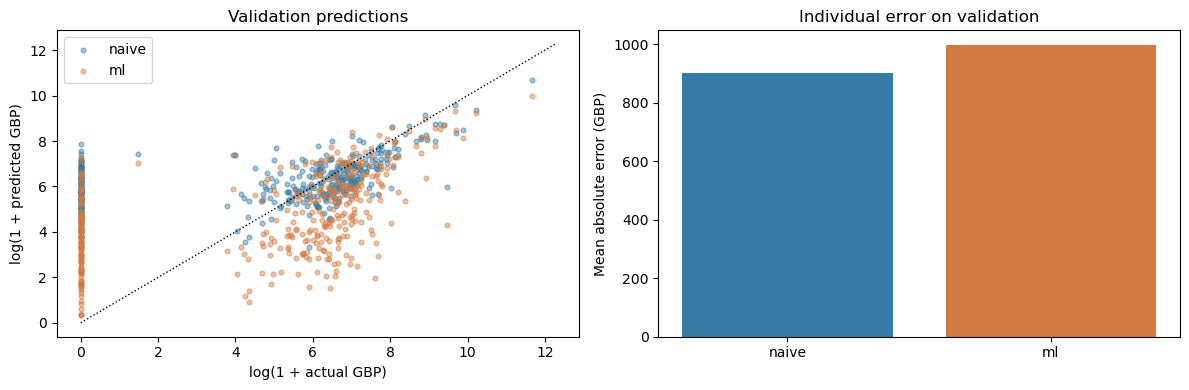

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, color in [("naive", "#367ba5"), ("ml", "#d17a42")]:
    axes[0].scatter(np.log1p(validation["holdout_revenue"]),
                    np.log1p(validation[f"pred_revenue_{name}"]),
                    s=12, alpha=0.45, label=name, color=color)
limit = max(axes[0].get_xlim()[1], axes[0].get_ylim()[1])
axes[0].plot([0, limit], [0, limit], ":", color="black", linewidth=1)
axes[0].set(title="Validation predictions", xlabel="log(1 + actual GBP)", ylabel="log(1 + predicted GBP)")
axes[0].legend()

mae_by_model = comparison.set_index("model").loc[["naive", "ml"], "mae"]
axes[1].bar(mae_by_model.index, mae_by_model.values, color=["#367ba5", "#d17a42"])
axes[1].set(title="Individual error on validation", ylabel="Mean absolute error (GBP)")
fig.tight_layout(); plt.show(); plt.close(fig)

**Reading the prediction plots.** Many validation customers have zero holdout
revenue but positive forecasts from both methods -- neither model predicts a hard zero
for anyone. Among customers who did buy again, ML's points cluster more often below the
diagonal, meaning it more often under-predicts, and both models visibly miss the largest
observed purchase. The bar chart is just the headline MAE gap in picture form. Log axes
make the full spend range visible but don't change the underlying GBP-scale error.

### What drives the ML forecasts?

Munro's article suggests reading a fitted CLV model's feature importances as a business
insight in their own right -- if frequency dominates, invest in repeat-visit nudges; if
recency dominates, invest in win-back timing. The article also floats predicting a CLV
*tier* (classification) rather than an exact revenue figure (regression) as a more
directly actionable alternative -- neither this notebook nor the first iteration
implements that alternative, so it's named here as a road not taken rather than a
comparison actually run.

Applying the article's suggestion to both ML models here, mainly to check whether it
holds up rather than to assume it does.

In [13]:
importance = pd.DataFrame({
    "feature": FEATURE_COLS,
    "unconditional_importance": ml_model.feature_importances_,
    "conditional_active_importance": active_model.feature_importances_,
}).sort_values("unconditional_importance", ascending=False)
importance.round(3)

,feature,unconditional_importance,conditional_active_importance
1,revenue_cal,0.563,0.789
7,recency_to_tenure_cal,0.112,0.011
6,orders_per_30_days_cal,0.085,0.035
2,mean_order_value_cal,0.070,0.126
3,recency_days_cal,0.061,0.016
0,orders_cal,0.060,0.008
4,tenure_days_cal,0.026,0.011
5,purchase_span_days_cal,0.023,0.005


**Reading CLV feature importance.** `revenue_cal` dominates both models, and more
so for the conditional-active model (0.789) than the unconditional one (0.563) -- past
spend predicting future spend, which is the least surprising story a CLV model could
tell. The more interesting comparison is against notebook 4's churn model, where
`recency_to_tenure_cal` was the second-most-important feature by a wide margin (0.224).
Here it barely registers for the conditional-active model (0.011), though it still
carries real weight unconditionally (0.112). That divergence makes sense once stated
plainly: recency is informative about *whether* a customer returns, much less so about
*how much* they spend once they do -- and the conditional-active model, answering
exactly that second question, has correspondingly little use for it. This matters
beyond curiosity, since the conditional-active model is what notebook 5's
false-negative cost proxy is actually built from.

## 5. Export the conditional-value proxy for policy economics

**Why this is a separate export from the head-to-head comparison above.** Notebook 5
needs a dollar figure to put on "missing a customer who was actually going to churn" --
and using the *unconditional* ML forecast for that would be circular: a customer flagged
as high-risk (because their predicted purchase probability is low) would, by the same
logic, tend to have a low unconditional revenue forecast, making them look cheap to
miss for the wrong reason. The conditional-active model instead estimates "how much
would this customer spend *if* they come back" -- trained only on customers who did.
Multiplying that by an illustrative 25% margin gives a decision proxy for false-negative
cost, not a claim about actual recoverable profit; the real effect of any outreach is
unobserved in this dataset.

In [14]:
MARGIN = 0.25
features["pred_revenue_cost"] = features["pred_revenue_if_active"].clip(lower=0)
features["fn_cost_illustrative"] = MARGIN * features["pred_revenue_cost"]

policy_export = features.loc[~train_mask, ["CustomerID", "split", "holdout_revenue", "segment",
                                            "pred_revenue_naive", "pred_revenue_ml", "pred_revenue_prob",
                                            "pred_revenue_if_active", "pred_revenue_cost", "fn_cost_illustrative"]]
assert set(policy_export["CustomerID"]) == set(manifest.loc[manifest["split"].isin(["validation", "test"]), "CustomerID"])
assert policy_export["fn_cost_illustrative"].notna().all()

full_features = features[["CustomerID", "split"] + FEATURE_COLS + ["churned", "holdout_revenue"]]
full_features.to_parquet(PROCESSED_DATA / "retail_features.parquet", index=False)
policy_export.to_parquet(PROCESSED_DATA / "retail_clv_policy_inputs.parquet", index=False)
print("Saved complete calibration features and train-fitted conditional-value estimates for validation/test")

Saved complete calibration features and train-fitted conditional-value estimates for validation/test


### Summary

- The naive rate-extrapolation baseline beats a train-fitted ML model on
  individual-customer accuracy (£900.71 vs £996.92 MAE), though the gap shrinks by more
  than half once a single very large customer is excluded from both.
- Both models under-predict aggregate holdout revenue -- naive by about 27%, ML by
  about 57% -- confirming neither is a reliable revenue forecaster at this level either.
- **BG-NBD/Gamma-Gamma fails its own suitability gate**: Gamma-Gamma's fitted `q <= 1`
  makes its population-mean formula undefined, giving 0% usable prediction coverage.
  This is a genuine fit-for-purpose finding for this dataset's large one-time-buyer
  population, not a general indictment of the method.
- A separate **conditional-active spend model**, fit only on customers who actually
  purchased again, is exported as notebook 5's false-negative cost proxy -- kept
  distinct from the unconditional forecast specifically to avoid making high-risk
  customers look artificially cheap to miss.

**Next:** `04_Churn_Model.ipynb` -- fit and validate models predicting the probability
of *no* purchase in the holdout window, using the same calibration features.